# Phase Diagram for Optimal Control Problem

System of differential equations:
$$\dot{c} = \frac{\delta}{n} c$$
$$\dot{s} = \frac{\delta}{n} s - c$$

with boundary condition $s(0) = s(T)$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

plt.rcParams['figure.figsize'] = [10, 10]
plt.rcParams['font.size'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

## Parameters and System Definition

In [2]:
# Parameters (example values)
delta = 0.5
n = 2
T = 5

# Derived constant
alpha = delta / n

print(f"Parameters: δ = {delta}, n = {n}, T = {T}")
print(f"α = δ/n = {alpha}")

def system(X, t):
    c, s = X
    dc = alpha * c
    ds = alpha * s - c
    return [dc, ds]

def system_backward(X, t):
    """For backward integration"""
    c, s = X
    dc = -alpha * c
    ds = -(alpha * s - c)
    return [dc, ds]

# Jacobian
J = np.array([[alpha, 0],
              [-1, alpha]])

eigenvalues, eigenvectors = np.linalg.eig(J)
print(f"\nJacobian Matrix:")
print(J)
print(f"\nEigenvalues: λ₁ = λ₂ = {eigenvalues[0]:.4f} (repeated)")
print(f"Classification: Unstable improper node (both eigenvalues positive)")

Parameters: δ = 0.5, n = 2, T = 5
α = δ/n = 0.25

Jacobian Matrix:
[[ 0.25  0.  ]
 [-1.    0.25]]

Eigenvalues: λ₁ = λ₂ = 0.2500 (repeated)
Classification: Unstable improper node (both eigenvalues positive)


## Analytical Solutions

In [3]:
def optimal_c(t, A, delta, n):
    """Optimal control: c(t) = A * exp(δt/n)"""
    return A * np.exp(delta * t / n)

def optimal_s(t, A, B, delta, n):
    """Optimal state: s(t) = (B - At) * exp(δt/n)"""
    return (B - A * t) * np.exp(delta * t / n)

def find_constants(s0, delta, n, T):
    """Find A and B from s(0) = s(T) = s0"""
    theta = np.exp(delta * T / n)
    # B = s0
    # s(T) = (B - AT) * theta = s0
    # B - AT = s0 / theta
    # s0 - AT = s0 / theta
    # AT = s0 - s0/theta = s0(1 - 1/theta) = s0(theta-1)/theta
    # A = s0(theta-1)/(T*theta)
    B = s0
    A = s0 * (theta - 1) / (T * theta)
    return A, B

# Example with s(0) = 10
s0 = 10
A, B = find_constants(s0, delta, n, T)
print(f"For s(0) = {s0}:")
print(f"  A = {A:.6f}")
print(f"  B = {B:.6f}")
print(f"\nVerification:")
print(f"  s(0) = {optimal_s(0, A, B, delta, n):.6f}")
print(f"  s(T) = {optimal_s(T, A, B, delta, n):.6f}")

For s(0) = 10:
  A = 1.426990
  B = 10.000000

Verification:
  s(0) = 10.000000
  s(T) = 10.000000


## Generate Phase Diagram

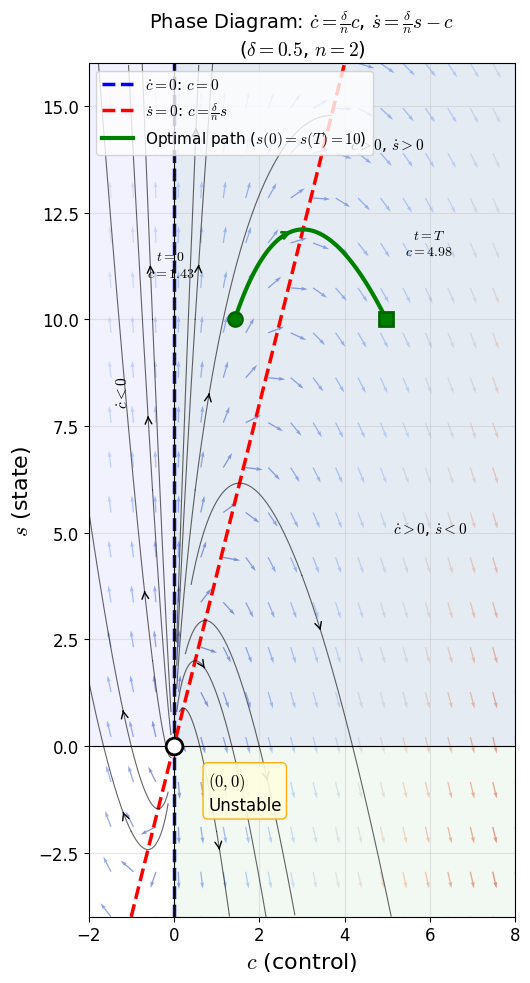


Saved: phase_diagram_p2.pdf and phase_diagram_p2.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot range
c_min, c_max = -2, 8
s_min, s_max = -4, 16

# Grid for vector field
c_grid = np.linspace(c_min, c_max, 20)
s_grid = np.linspace(s_min, s_max, 20)
C, S = np.meshgrid(c_grid, s_grid)

# Vector field
DC = alpha * C
DS = alpha * S - C

# Normalize for visualization
magnitude = np.sqrt(DC**2 + DS**2)
magnitude[magnitude == 0] = 1  # Avoid division by zero
DC_norm = DC / magnitude
DS_norm = DS / magnitude

# Plot vector field
ax.quiver(C, S, DC_norm, DS_norm, magnitude, cmap='coolwarm', alpha=0.6, scale=25)

# Nullclines
s_range = np.linspace(s_min, s_max, 100)

# dc/dt = 0 nullcline: c = 0 (vertical line)
ax.axvline(x=0, color='blue', linestyle='--', linewidth=2.5, label=r'$\dot{c} = 0$: $c = 0$')

# ds/dt = 0 nullcline: c = (δ/n)s
c_nullcline = alpha * s_range
ax.plot(c_nullcline, s_range, 'r--', linewidth=2.5, label=r'$\dot{s} = 0$: $c = \frac{\delta}{n}s$')

# General trajectories (forward in time)
t_forward = np.linspace(0, 8, 500)
t_backward = np.linspace(0, 8, 500)

# Initial conditions for general trajectories
ics_forward = [
    (0.5, 2), (0.5, 6), (0.5, 10), (0.5, 14),
    (1, -2), (2, 0), (3, 4),
    (-0.5, 2), (-0.5, 6), (-0.5, 10),
    (-1, -2), (-1, 0)
]

for c0, s0_ic in ics_forward:
    sol = odeint(system, [c0, s0_ic], t_forward)
    # Only plot within bounds
    mask = (sol[:, 0] >= c_min) & (sol[:, 0] <= c_max) & (sol[:, 1] >= s_min) & (sol[:, 1] <= s_max)
    if np.any(mask):
        ax.plot(sol[mask, 0], sol[mask, 1], 'k-', linewidth=0.8, alpha=0.6)
        # Add arrow
        valid_indices = np.where(mask)[0]
        if len(valid_indices) > 10:
            mid = valid_indices[len(valid_indices)//4]
            if mid < len(sol) - 1:
                ax.annotate('', xy=(sol[mid+1, 0], sol[mid+1, 1]),
                           xytext=(sol[mid, 0], sol[mid, 1]),
                           arrowprops=dict(arrowstyle='->', color='black', lw=1))

# Backward trajectories for complete picture
for c0, s0_ic in ics_forward:
    sol = odeint(system_backward, [c0, s0_ic], t_backward)
    mask = (sol[:, 0] >= c_min) & (sol[:, 0] <= c_max) & (sol[:, 1] >= s_min) & (sol[:, 1] <= s_max)
    if np.any(mask):
        ax.plot(sol[mask, 0], sol[mask, 1], 'k-', linewidth=0.8, alpha=0.6)

# Optimal trajectory satisfying s(0) = s(T)
s0_opt = 10
A_opt, B_opt = find_constants(s0_opt, delta, n, T)
t_opt = np.linspace(0, T, 200)
c_opt = optimal_c(t_opt, A_opt, delta, n)
s_opt = optimal_s(t_opt, A_opt, B_opt, delta, n)

ax.plot(c_opt, s_opt, 'g-', linewidth=3, label=f'Optimal path ($s(0)=s(T)={s0_opt}$)')
ax.plot(c_opt[0], s_opt[0], 'go', markersize=10, markeredgecolor='darkgreen', markeredgewidth=2, zorder=10)
ax.plot(c_opt[-1], s_opt[-1], 'gs', markersize=10, markeredgecolor='darkgreen', markeredgewidth=2, zorder=10)
ax.annotate(f'$t=0$\n$c={c_opt[0]:.2f}$', xy=(c_opt[0], s_opt[0]), xytext=(c_opt[0]-1.5, s_opt[0]+1),
           fontsize=10, ha='center')
ax.annotate(f'$t=T$\n$c={c_opt[-1]:.2f}$', xy=(c_opt[-1], s_opt[-1]), xytext=(c_opt[-1]+1, s_opt[-1]+1.5),
           fontsize=10, ha='center')

# Add arrow on optimal trajectory
mid_opt = len(t_opt) // 2
ax.annotate('', xy=(c_opt[mid_opt+5], s_opt[mid_opt+5]),
           xytext=(c_opt[mid_opt], s_opt[mid_opt]),
           arrowprops=dict(arrowstyle='->', color='green', lw=2))

# Equilibrium point
ax.plot(0, 0, 'ko', markersize=12, markerfacecolor='white', markeredgewidth=2, zorder=10)
ax.annotate('$(0, 0)$\nUnstable', xy=(0, 0), xytext=(0.8, -1.5),
           fontsize=12, ha='left',
           bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange', alpha=0.9))

# Shade economically relevant region
ax.axvspan(0, c_max, alpha=0.05, color='green')
ax.axhspan(0, s_max, alpha=0.05, color='blue')

# Add region labels
ax.text(5, 14, r'$\dot{c} > 0$, $\dot{s} > 0$', fontsize=11, ha='center')
ax.text(6, 5, r'$\dot{c} > 0$, $\dot{s} < 0$', fontsize=11, ha='center')
ax.text(-1.2, 8, r'$\dot{c} < 0$', fontsize=11, ha='center', rotation=90)

# Formatting
ax.set_xlim(c_min, c_max)
ax.set_ylim(s_min, s_max)
ax.set_xlabel(r'$c$ (control)', fontsize=16)
ax.set_ylabel(r'$s$ (state)', fontsize=16)
ax.set_title(r'Phase Diagram: $\dot{c} = \frac{\delta}{n}c$, $\dot{s} = \frac{\delta}{n}s - c$' + 
             f'\n($\\delta={delta}$, $n={n}$)', fontsize=14)
ax.legend(loc='upper left', fontsize=11)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.8)
ax.axvline(x=0, color='k', linewidth=0.8)

plt.tight_layout()
plt.savefig('phase_diagram_p2.pdf', dpi=300, bbox_inches='tight')
plt.savefig('phase_diagram_p2.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: phase_diagram_p2.pdf and phase_diagram_p2.png")

## Summary

**System:**
- $\dot{c} = \frac{\delta}{n} c$
- $\dot{s} = \frac{\delta}{n} s - c$

**Equilibrium:** $(c^*, s^*) = (0, 0)$ — unstable improper node

**Eigenvalues:** $\lambda_1 = \lambda_2 = \frac{\delta}{n} > 0$ (repeated)

**Optimal solutions:**
- $c(t) = A e^{\frac{\delta t}{n}}$ with $A > 0$
- $s(t) = (B - At) e^{\frac{\delta t}{n}}$

**Key insight:** Since $A > 0$ and $e^{\frac{\delta t}{n}} > 0$, the optimal control $c(t) > 0$ always.